In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [4]:
df = df.dropna(subset=["Rating"])

In [5]:
df["Year"] = df["Year"].astype(str).str.replace(r"[()]", "", regex=True)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

df["Duration"] = df["Duration"].astype(str).str.replace(" min", "", regex=False)
df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")

df["Votes"] = df["Votes"].astype(str).str.replace(",", "", regex=False)
df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")

In [6]:
for col in ["Year", "Duration", "Votes"]:
    df[col] = df[col].fillna(df[col].median())

for col in ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]:
    df[col] = df[col].fillna("Unknown")

In [7]:
df["Main_Genre"] = df["Genre"].apply(lambda x: x.split(",")[0].strip() if isinstance(x, str) else "Unknown")
df["Genre_Count"] = df["Genre"].apply(lambda x: len(x.split(",")) if isinstance(x, str) else 1)

In [8]:
director_freq = df["Director"].value_counts()
actor1_freq = df["Actor 1"].value_counts()
actor2_freq = df["Actor 2"].value_counts()
actor3_freq = df["Actor 3"].value_counts()

df["Director_Freq"] = df["Director"].map(director_freq)
df["Actor1_Freq"] = df["Actor 1"].map(actor1_freq)
df["Actor2_Freq"] = df["Actor 2"].map(actor2_freq)
df["Actor3_Freq"] = df["Actor 3"].map(actor3_freq)

In [9]:
X = df[["Year", "Duration", "Votes", "Genre_Count", "Director_Freq", "Actor1_Freq", "Actor2_Freq", "Actor3_Freq", "Main_Genre"]]
y = df["Rating"]

In [10]:
X = pd.get_dummies(X, columns=["Main_Genre"], drop_first=True)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [14]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [15]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.8191332070707071
RMSE: 1.0843186124104378
R2: 0.3675873779207206


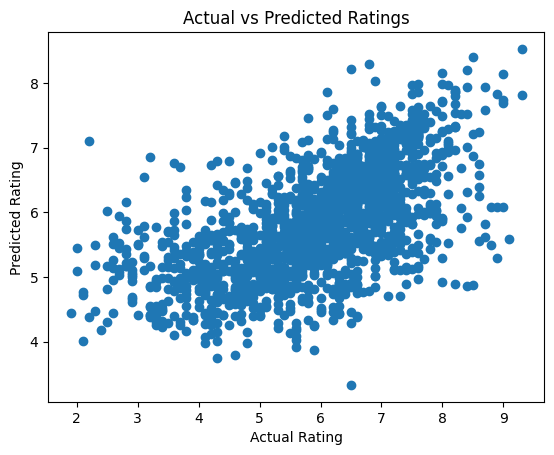

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [20]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

In [21]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [22]:
df.shape

(15509, 10)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [24]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [25]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [26]:
df = df.dropna(subset=["Rating"])

In [27]:
df["Year"] = df["Year"].astype(str)

df["Year"] = df["Year"].str.extract(r'(\d{4})')

df["Year"] = pd.to_numeric(
    df["Year"],
    errors='coerce'
)

In [28]:
df["Duration"] = df["Duration"].astype(str)

df["Duration"] = df["Duration"].str.replace(
    " min",
    "",
    regex=False
)

df["Duration"] = pd.to_numeric(
    df["Duration"],
    errors='coerce'
)

In [29]:
df["Votes"] = df["Votes"].astype(str)

df["Votes"] = df["Votes"].str.replace(
    ",",
    "",
    regex=False
)

df["Votes"] = pd.to_numeric(
    df["Votes"],
    errors='coerce'
)

In [30]:
for col in ["Year","Duration","Votes"]:
    df[col] = df[col].fillna(df[col].median())

In [31]:
for col in [
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3"
]:
    df[col] = df[col].fillna("Unknown")

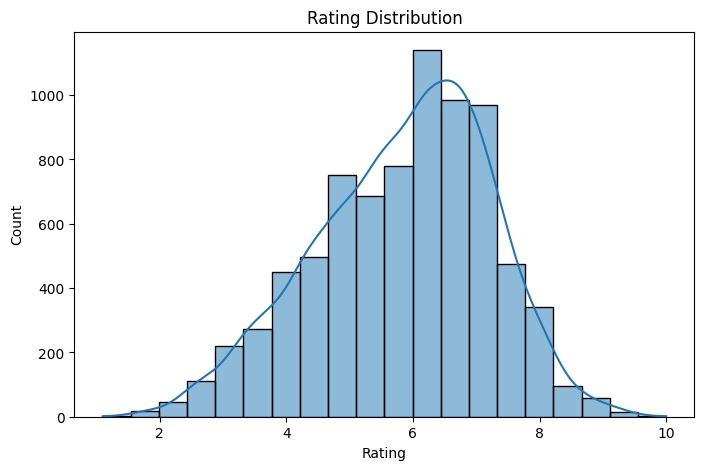

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Rating"],
    bins=20,
    kde=True
)

plt.title("Rating Distribution")

plt.show()

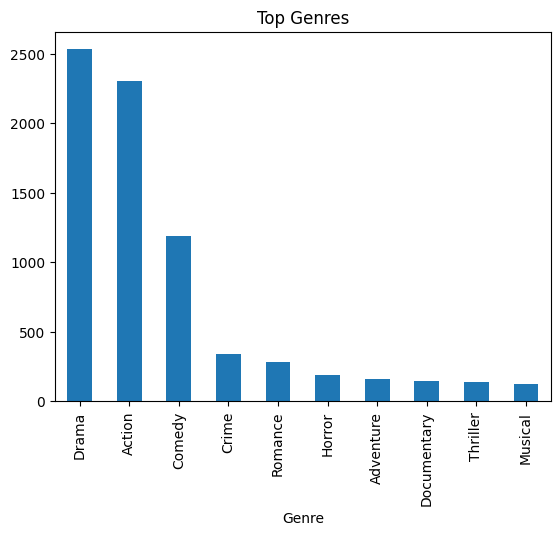

In [33]:
top_genres = (
    df["Genre"]
    .str.split(",")
    .str[0]
    .value_counts()
    .head(10)
)

top_genres.plot(
    kind="bar"
)

plt.title("Top Genres")

plt.show()

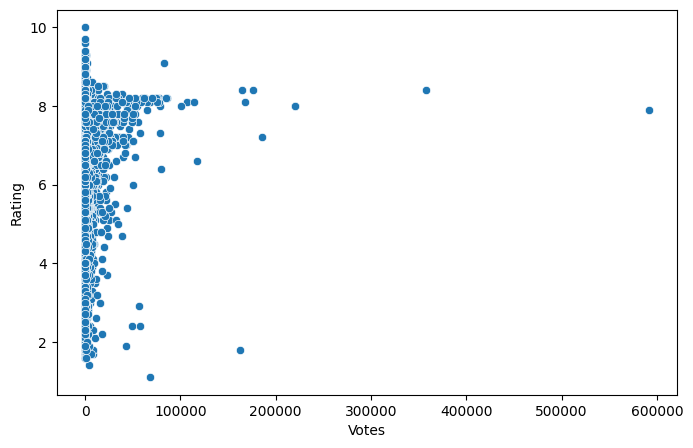

In [34]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Votes",
    y="Rating",
    data=df
)

plt.show()

In [35]:
df["Main_Genre"] = df["Genre"].apply(
    lambda x:
    x.split(",")[0].strip()
)

In [36]:
df["Genre_Count"] = df["Genre"].apply(
    lambda x:
    len(x.split(","))
)

In [37]:
director_freq = (
    df["Director"]
    .value_counts()
)

df["Director_Freq"] = (
    df["Director"]
    .map(director_freq)
)

In [38]:
actor1_freq = (
    df["Actor 1"]
    .value_counts()
)

actor2_freq = (
    df["Actor 2"]
    .value_counts()
)

actor3_freq = (
    df["Actor 3"]
    .value_counts()
)

df["Actor1_Freq"] = (
    df["Actor 1"]
    .map(actor1_freq)
)

df["Actor2_Freq"] = (
    df["Actor 2"]
    .map(actor2_freq)
)

df["Actor3_Freq"] = (
    df["Actor 3"]
    .map(actor3_freq)
)

In [39]:
X = df[
[
    "Year",
    "Duration",
    "Votes",
    "Genre_Count",
    "Director_Freq",
    "Actor1_Freq",
    "Actor2_Freq",
    "Actor3_Freq",
    "Main_Genre"
]
]

In [40]:
y = df["Rating"]

In [41]:
X = pd.get_dummies(
    X,
    columns=["Main_Genre"],
    drop_first=True
)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

In [44]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [45]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

gb_pred = gb.predict(X_test)

In [46]:
def evaluate_model(
    name,
    y_test,
    predictions
):
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    print(name)

    print("MAE:", mae)

    print("RMSE:", rmse)

    print("R2:", r2)

    print()

In [47]:
evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred
)

Linear Regression
MAE: 0.9823323836604765
RMSE: 1.23633269528674
R2: 0.1778379750885366

Random Forest
MAE: 0.8191332070707071
RMSE: 1.0843186124104378
R2: 0.3675873779207206

Gradient Boosting
MAE: 0.8180193175147418
RMSE: 1.07862620830602
R2: 0.3742099678981873



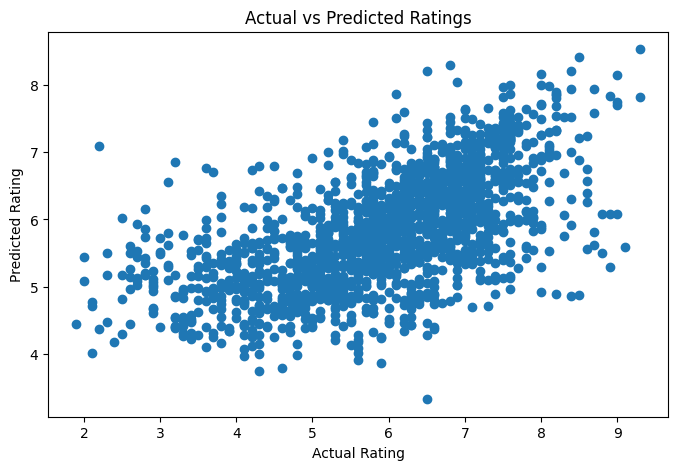

In [48]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Rating")

plt.ylabel("Predicted Rating")

plt.title(
    "Actual vs Predicted Ratings"
)

plt.show()

In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                   Feature  Importance
2                    Votes    0.247487
0                     Year    0.219594
1                 Duration    0.106464
5              Actor1_Freq    0.073374
4            Director_Freq    0.070007
6              Actor2_Freq    0.067284
7              Actor3_Freq    0.066464
13  Main_Genre_Documentary    0.038065
3              Genre_Count    0.028681
14        Main_Genre_Drama    0.021464


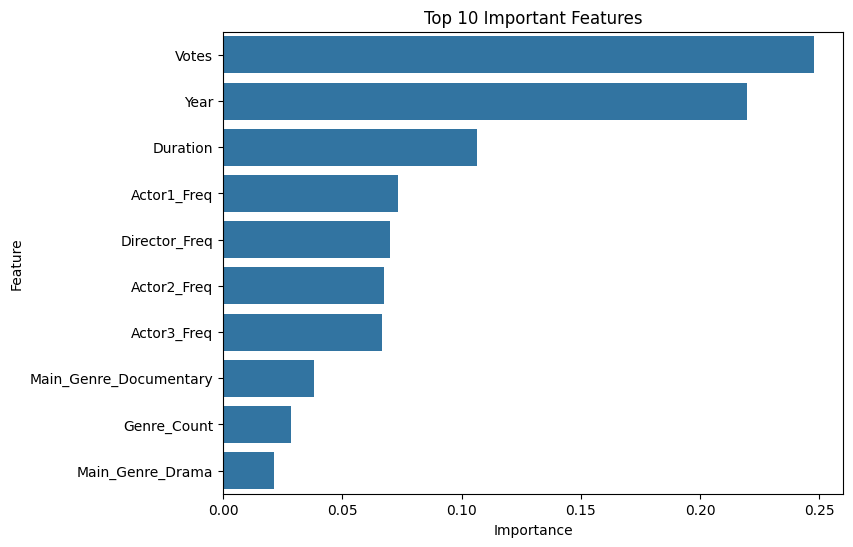

In [50]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()